# Notebook 04 — ERM & Generalization Theory
**DSC 240 · Machine Learning · UCSD**

How do we know that minimizing training loss will generalize? This notebook builds the answer from first principles:

1. **Hoeffding inequality** — concentration for a single function
2. **Union bound** — extending to finite hypothesis classes
3. **VC dimension** — handling infinite hypothesis classes
4. **Shattering** — what makes a hypothesis class "complex"?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

np.random.seed(0)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'bound': '#5b8dee', 'empirical': '#e05c6b', 'true': '#4caf81', 'highlight': '#f09c4a'}

## 1. Hoeffding's Inequality

For a **fixed** hypothesis h, the empirical loss $\hat{L}_n(h)$ concentrates around the true loss $L(h)$:

$$P\left(|\hat{L}_n(h) - L(h)| \geq t\right) \leq 2e^{-2nt^2}$$

Inverted: with probability at least $1-\delta$,

$$L(h) \leq \hat{L}_n(h) + \sqrt{\frac{\log(2/\delta)}{2n}}$$

The bound shrinks as $O(1/\sqrt{n})$.

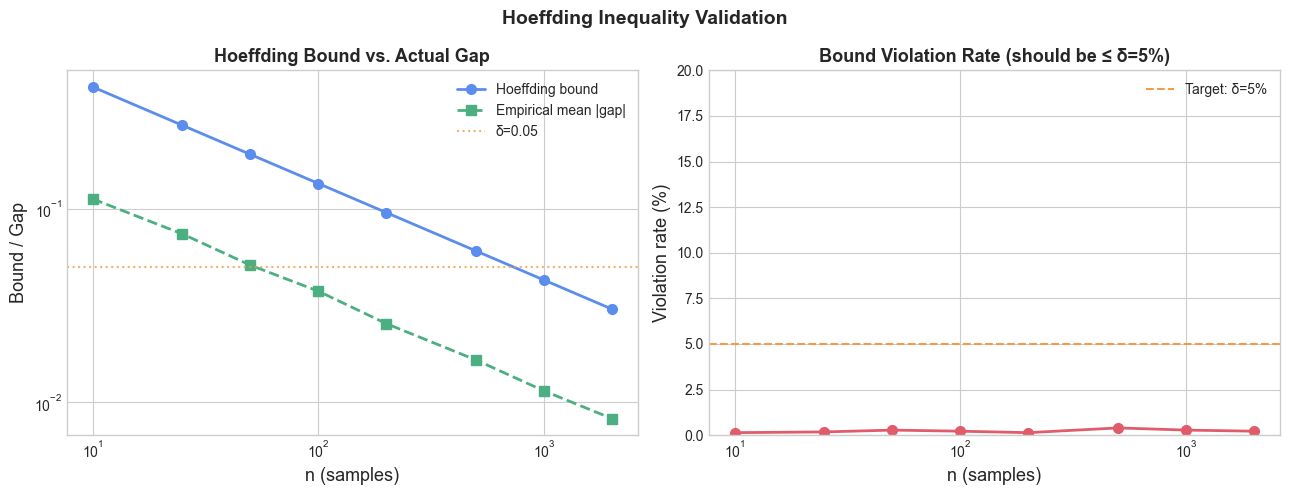

Bound always holds: True


In [3]:
# Verify empirically: simulate sampling a fixed classifier
true_error = 0.3  # the fixed classifier has this true error
delta = 0.05
n_values = [10, 25, 50, 100, 200, 500, 1000, 2000]
n_trials = 5000

results = []
for n in n_values:
    # Simulate n_trials draws of the empirical error
    emp_errors = np.random.binomial(n, true_error, size=n_trials) / n
    gaps = np.abs(emp_errors - true_error)
    # Hoeffding bound
    bound = np.sqrt(np.log(2/delta) / (2*n))
    # Fraction of times the gap exceeded the bound
    violation_rate = np.mean(gaps > bound)
    results.append((n, bound, violation_rate, np.mean(gaps), np.std(gaps)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ns = [r[0] for r in results]
bounds = [r[1] for r in results]
violations = [r[2] for r in results]
mean_gaps = [r[3] for r in results]

ax = axes[0]
ax.loglog(ns, bounds, 'o-', color=COLORS['bound'], lw=2, ms=7, label='Hoeffding bound')
ax.loglog(ns, mean_gaps, 's--', color=COLORS['true'], lw=2, ms=7, label='Empirical mean |gap|')
ax.axhline(delta, color=COLORS['highlight'], ls=':', lw=1.5, alpha=0.8, label=f'δ={delta}')
ax.set_xlabel('n (samples)', fontsize=13)
ax.set_ylabel('Bound / Gap', fontsize=13)
ax.set_title('Hoeffding Bound vs. Actual Gap', fontsize=13, fontweight='bold')
ax.legend()

ax = axes[1]
ax.semilogx(ns, [v*100 for v in violations], 'o-', color=COLORS['empirical'], lw=2, ms=7)
ax.axhline(delta*100, color=COLORS['highlight'], ls='--', lw=1.5, label=f'Target: δ={delta*100:.0f}%')
ax.set_xlabel('n (samples)', fontsize=13)
ax.set_ylabel('Violation rate (%)', fontsize=13)
ax.set_title('Bound Violation Rate (should be ≤ δ=5%)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 20)
ax.legend()

plt.suptitle('Hoeffding Inequality Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/figures/hoeffding_validation.png', dpi=120)
plt.show()

print('Bound always holds:', all(v <= delta + 0.01 for v in violations))

## 2. Union Bound — Finite Hypothesis Classes

For **any** h ∈ H (a finite set with |H| = M classifiers), using the union bound:

$$P\left(\exists h \in H: |\hat{L}_n(h) - L(h)| \geq t\right) \leq 2M \cdot e^{-2nt^2}$$

The generalization bound becomes:
$$\forall h \in H: \quad L(h) \leq \hat{L}_n(h) + \underbrace{\sqrt{\frac{\log(2M/\delta)}{2n}}}_{\text{complexity penalty}}$$

**Key insight:** More classifiers to choose from → looser bound (logarithmically).

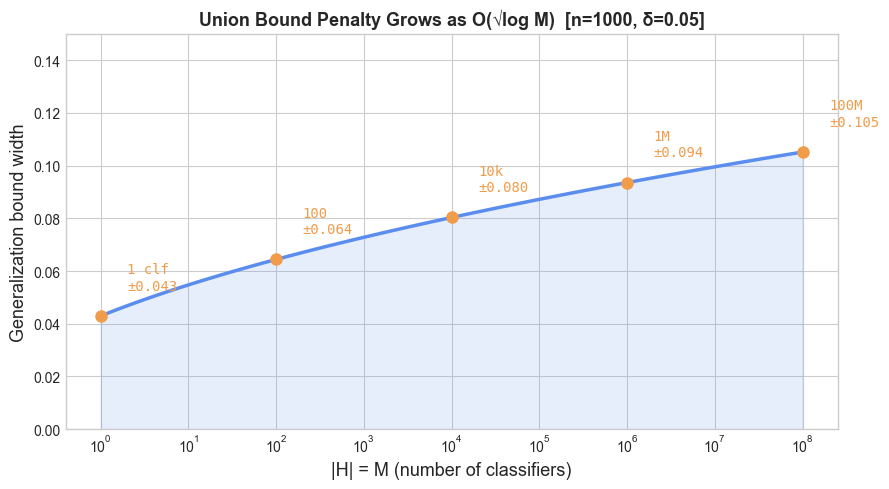

In [4]:
n = 1000
delta = 0.05
Ms = np.logspace(0, 8, 100)  # M from 1 to 10^8

bounds_M = np.sqrt(np.log(2*Ms/delta) / (2*n))

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(Ms, bounds_M, color=COLORS['bound'], lw=2.5)
ax.fill_between(Ms, 0, bounds_M, alpha=0.15, color=COLORS['bound'])

# Annotate key points
for M_mark, label in [(1, '1 clf'), (100, '100'), (1e4, '10k'), (1e6, '1M'), (1e8, '100M')]:
    b = np.sqrt(np.log(2*M_mark/delta) / (2*n))
    ax.plot(M_mark, b, 'o', color=COLORS['highlight'], ms=8, zorder=5)
    ax.annotate(f'{label}\n±{b:.3f}', (M_mark, b), 
                xytext=(M_mark*2, b+0.01), fontsize=10,
                color=COLORS['highlight'], fontfamily='monospace')

ax.set_xlabel('|H| = M (number of classifiers)', fontsize=13)
ax.set_ylabel('Generalization bound width', fontsize=13)
ax.set_title(f'Union Bound Penalty Grows as O(√log M)  [n={n}, δ={delta}]', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.15)
plt.tight_layout()
plt.savefig('../assets/figures/union_bound.png', dpi=120)
plt.show()

## 3. VC Dimension

Finite sets are rarely interesting — most useful hypothesis classes are **infinite**. VC theory handles this.

**Definitions:**
- H **shatters** {x₁,...,xₙ} if for every binary labeling, some h ∈ H achieves it
- **VC dimension** = size of the largest set that H can shatter

**Key result:** Linear classifiers in ℝᵈ have VC dimension **d+1**.

**VC bound:**
$$L(c_{ERM}) \leq L_{emp}(c_{ERM}) + \sqrt{\frac{h\left(\log\frac{2n}{h}+1\right) - \log(\varepsilon/4)}{n}}$$

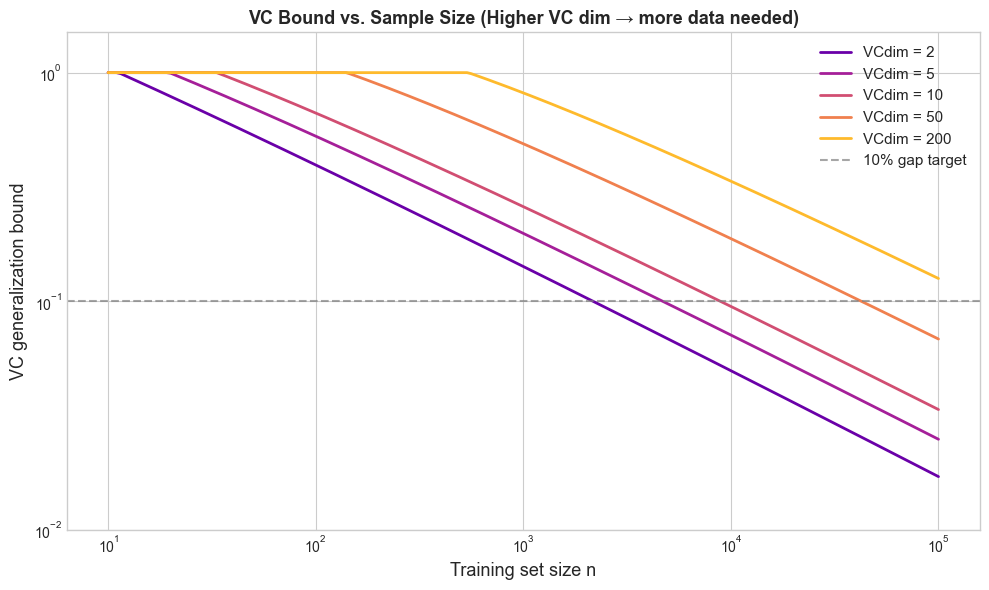

In [5]:
# VC bound as a function of n (for different VC dimensions)
def vc_bound(n, h_vc, epsilon=0.05):
    """VC generalization bound."""
    if n <= h_vc:
        return 1.0  # vacuous when n is too small
    return np.sqrt((h_vc * (np.log(2*n/h_vc) + 1) - np.log(epsilon/4)) / n)

ns = np.logspace(1, 5, 200)
vc_dims = [2, 5, 10, 50, 200]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0.2, 0.85, len(vc_dims)))

for h_vc, color in zip(vc_dims, colors):
    bounds = [min(vc_bound(n, h_vc), 1.0) for n in ns]
    ax.loglog(ns, bounds, lw=2, color=color, label=f'VCdim = {h_vc}')

ax.axhline(0.1, color='gray', ls='--', lw=1.5, alpha=0.7, label='10% gap target')
ax.set_xlabel('Training set size n', fontsize=13)
ax.set_ylabel('VC generalization bound', fontsize=13)
ax.set_title('VC Bound vs. Sample Size (Higher VC dim → more data needed)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0.01, 1.5)
plt.tight_layout()
plt.savefig('../assets/figures/vc_bound.png', dpi=120)
plt.show()

## 4. Shattering in 2D — Visual Demo

A linear classifier in ℝ² **can** shatter 3 points (in general position) but **cannot** shatter 4 points.  
Hence VCdim(linear classifiers in ℝ²) = 3.

C:\Users\aldai\AppData\Local\Temp\ipykernel_33904\3934894873.py:34: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aldai\AppData\Local\Temp\ipykernel_33904\3934894873.py:34: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aldai\AppData\Local\Temp\ipykernel_33904\3934894873.py:35: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('../assets/figures/shattering.png', dpi=110)
C:\Users\aldai\AppData\Local\Temp\ipykernel_33904\3934894873.py:35: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) Arial.
  plt.savefig('../assets/figures/shattering.png', dpi=110)
d:\GitHub\ml-concepts\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\GitHub\ml-concepts\.venv\Lib\site-packages\IPython\core\pylabtools.py:1

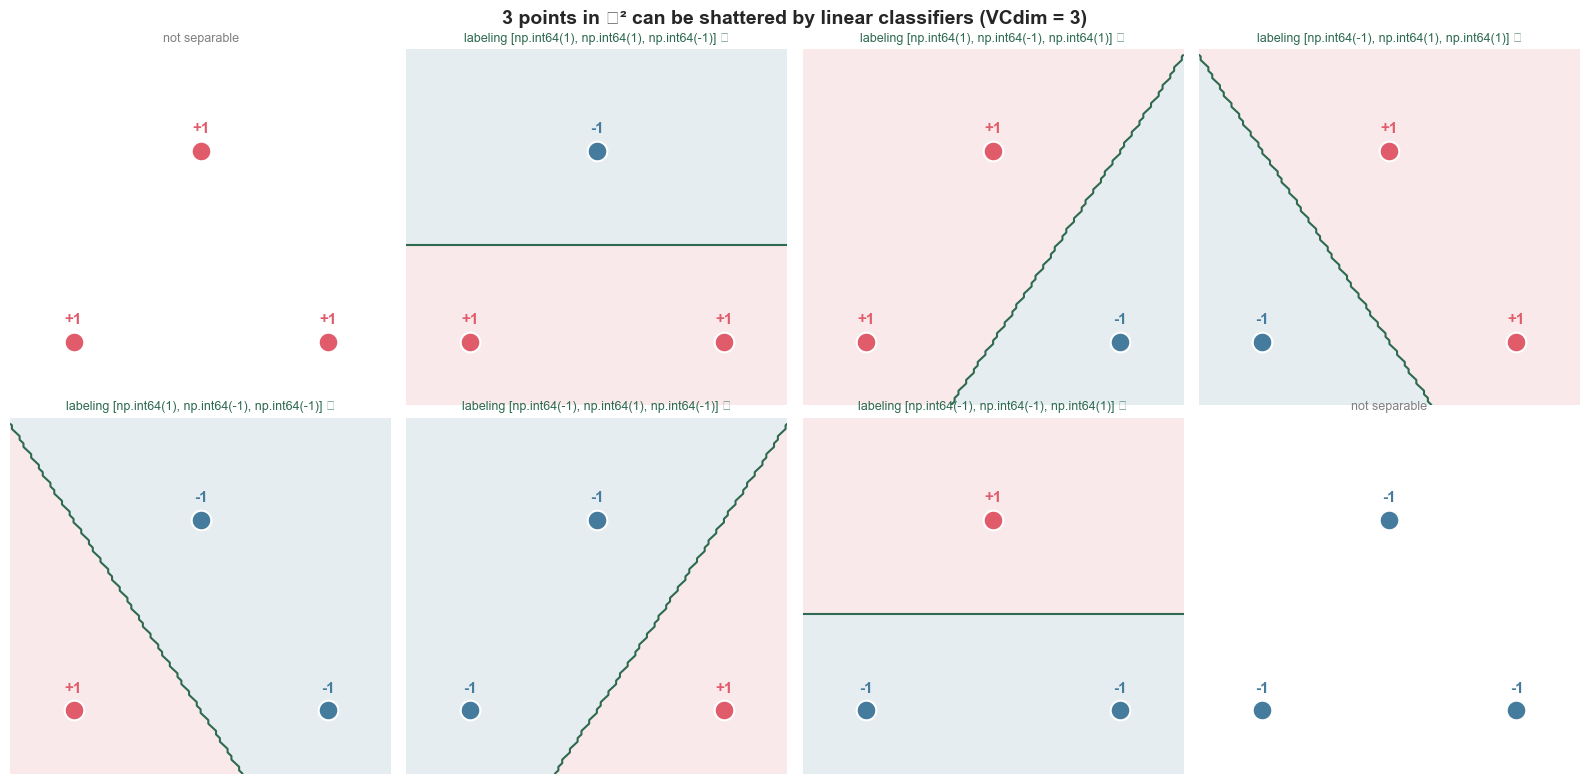

In [6]:
# Show all 2^3 = 8 labelings of 3 points and that a linear classifier achieves each
pts3 = np.array([[0, 0], [2, 0], [1, 1.5]])
labels_all = np.array([[1,1,1],[1,1,-1],[1,-1,1],[-1,1,1],
                        [1,-1,-1],[-1,1,-1],[-1,-1,1],[-1,-1,-1]])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, labels in zip(axes.flat, labels_all):
    for p, l in zip(pts3, labels):
        c = '#e05c6b' if l == 1 else '#457B9D'
        ax.scatter(*p, c=c, s=200, zorder=5, edgecolors='white', linewidth=1.5)
        ax.text(p[0], p[1]+0.12, f'{l:+d}', ha='center', va='bottom', fontsize=11, fontweight='bold', color=c)

    # Find a separating hyperplane (or show XOR failure)
    # Simple approach: use sklearn
    from sklearn.svm import SVC
    clf = SVC(kernel='linear', C=1e6)
    try:
        clf.fit(pts3, labels)
        # Draw boundary
        xlim, ylim = [-0.5, 2.5], [-0.5, 2.3]
        xx2, yy2 = np.meshgrid(np.linspace(*xlim, 100), np.linspace(*ylim, 100))
        Z2 = clf.predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)
        ax.contourf(xx2, yy2, Z2, levels=[-2,0,2], colors=['#457B9D22','#e05c6b22'])
        ax.contour(xx2, yy2, Z2, levels=[0], colors=['#2D6A4F'], linewidths=1.5)
        ax.set_title(f'labeling {list(labels)} ✓', fontsize=9, color='#2D6A4F')
    except:
        ax.set_title('not separable', fontsize=9, color='gray')
    
    ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 2.3)
    ax.set_aspect('equal'); ax.axis('off')

fig.suptitle('3 points in ℝ² can be shattered by linear classifiers (VCdim = 3)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/figures/shattering.png', dpi=110)
plt.show()

## Summary

```
Single function h:
  L(h) ≤ L̂_n(h) + √(log(2/δ) / 2n)

Finite class |H| = M:
  L(h) ≤ L̂_n(h) + √(log(2M/δ) / 2n)          [penalty: log M]

VC class with VCdim = d:
  L(h) ≤ L̂_n(h) + √(d·log(n/d) / n)            [penalty: d·log(n/d)]
```

**The WYSIWYG principle:** What you see on training data (empirical risk) approximates what you get on test data (expected risk), up to a complexity penalty that grows with model expressiveness and shrinks with data size.

**Limitation:** These bounds are vacuous for modern overparameterized models (VC dim >> n). This motivates the double descent theory. → `05_double_descent.ipynb`